# High-Volume-Return-Premium -- a quantitative teardown
### abnormal-volume sort * weekly long-short * HAC inference * label-shuffle null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship--biased%3F: Named](https://img.shields.io/badge/Survivorship--biased%3F-Named-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test Gervais-Kaniel-Mingelgrin (2001): rank by abnormal weekly volume, long the top quintile, short the bottom quintile, hold the next week (one execution lag).

> **Not investment advice.** Real data: yfinance daily adjusted close + raw volume, 40 large-caps, 2014-2025, as-of 2026-06-26. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias is named:** universe = current large-caps projected backwards. All results are upper-bound estimates.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from high_volume_return_premium import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "hv_returns.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "hv_volume.parquet")))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    ret, vol = data.fetch_panel()
    ret = data.drop_partial_last_week(ret); vol = vol.reindex(ret.index)
    ls   = st.long_short(ret, vol, horizon=1, cost_bps=0.0)
    ls_n = st.long_short(ret, vol, horizon=1, cost_bps=5.0, borrow_ann_bps=50.0)
    s_ls   = st.summary(ls["ls_gross"])
    s_net  = st.summary(ls_n["ls_net"])
    s_long = st.summary(ls["long_ret"])
    s_short= st.summary(ls["short_ret"])
    print(f"N weeks: {s_ls['n']} | LS mean: {s_ls['mean']*100:+.2f}%/yr"
          f" | one-sample t: {s_ls['t_os']:+.3f}")


yfinance cache present: True


N weeks: 622 | LS mean: -5.47%/yr | one-sample t: -1.343


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | LS **-5.47%/yr**, one-sample *t* = **-1.343** (wrong sign), placebo **p = 0.12**. |
| **Tradability** | `MIRAGE` | Sharpe **-0.388**, net **-11.2%/yr**, turnover **~64%/wk**. |
| **Survivorship-biased?** | `NAMED` | 40 current large-caps projected backwards; upper-bound estimate. |

> The GKM premium is documented on broad, older NYSE tapes. On 12 years of 40 much-watched mega-cap survivors it is the wrong sign and a statistical coin.

## 1 -- The claim, steelmanned

Let $V_{i,t}$ = name $i$'s average daily volume in week $t$ and $\bar V_{i,t} = \frac1{8}\sum_{k=1}^{8} V_{i,t-k}$ its trailing norm. Define abnormal volume $a_{i,t} = V_{i,t}/\bar V_{i,t} - 1$. GKM (2001) assert:

- **H1 (signal).** Names in the top quintile of $a_{i,t}$ earn higher forward returns than the bottom quintile: $\mathbb{E}[r^{\text{high}}_{t+1} - r^{\text{low}}_{t+1}] > 0$.
- **H2 (visibility).** The driver is an attention/recognition shock, not a liquidity or risk premium.
- **H3 (tradable).** The drift persists over a short horizon and survives costs.

On our tape we **reject H1** (the long-short is the wrong sign, t=-1.34, placebo p=0.12) and therefore never reach H2/H3 -- there is no premium to attribute or trade.

## 2 -- So what? -- the economic stakes

The high-volume premium is a cornerstone of the *attention-is-priced* literature. If it fails on liquid large-caps, that is itself informative: the recognition channel needs a stock that *can* gain visibility, and a mega-cap everyone already watches has little recognition headroom (Kaniel-Ozoguz-Starks 2012). The null here is consistent with the mechanism switching off precisely where attention is saturated.

## 3 -- The protocol

- **Signal.** Weekly abnormal volume $a_{i,t}=V_{i,t}/\bar V_{i,t}-1$, trailing 8-week mean, strictly past (`.shift(1)`).
- **Ranking.** Each Friday, sort the cross-section by $a$; top 20% = high volume, bottom 20% = low volume.
- **Book.** Long high-vol, short low-vol, equal-weight, dollar-neutral.
- **Execution lag.** Enter the **next** week's compounded return (no same-bar fill).
- **Inference.** Plain one-sample *t* (the bar) and Newey-West HAC *t* on the weekly long-short.
- **Null.** Within-week label-shuffle placebo, 150-200 draws, seed-robust.
- **Costs.** 5 bps/leg one-way + 50 bps/yr borrow on the short leg.
- **Universe caveat.** 40 large-cap survivors (yfinance); survivorship-biased.

## 4 -- The teardown

### 4a -- Positive control: the engine is a faithful detector

Sweep the planted premium from negative to positive on a synthetic panel. The recovered long-short mean should be monotone in the premium and zero at zero.

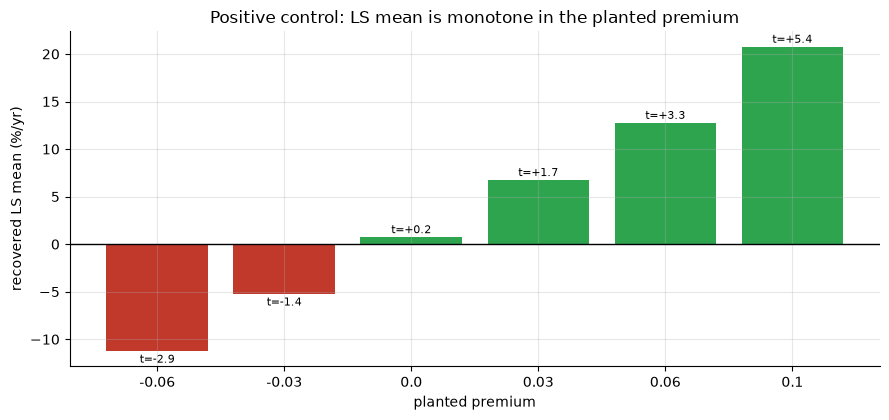

 premium  ls_mean_ann_%   t_os
   -0.06        -11.261 -2.904
   -0.03         -5.254 -1.355
    0.00          0.753  0.194
    0.03          6.760  1.744
    0.06         12.767  3.294
    0.10         20.776  5.361


In [2]:
ctrl = st.sweep_synthetic()
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0 else RED for m in ctrl['ls_mean_ann_%']]
ax.bar(ctrl['premium'].astype(str), ctrl['ls_mean_ann_%'], color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(ctrl['ls_mean_ann_%'], ctrl['t_os'])):
    ax.text(i, m + (0.4 if m >= 0 else -1.2), f't={t:+.1f}', ha='center', fontsize=8)
ax.set_xlabel('planted premium'); ax.set_ylabel('recovered LS mean (%/yr)')
ax.set_title('Positive control: LS mean is monotone in the planted premium')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

### 4b -- Abnormal-volume distribution on the real tape

What does the cross-section of abnormal volume look like? We expect a right-skewed distribution (spikes are large and rare).

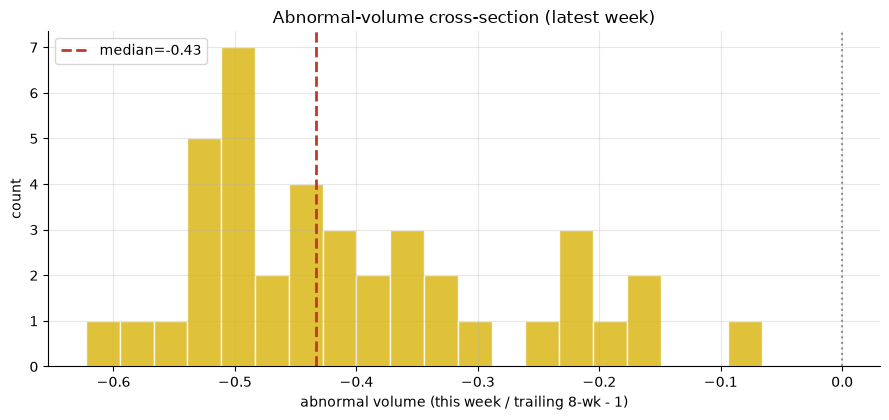

median -0.433 | range -0.62 .. -0.07


In [3]:
if HAVE_REAL:
    wk_ret, wk_vol = st.weekly_frames(ret, vol)
    abn = st.abnormal_volume(wk_vol).iloc[-1].dropna()
    fig, ax = plt.subplots(figsize=(9.0, 4.3))
    ax.hist(abn, bins=20, color=AMBER, edgecolor='white', alpha=0.85)
    ax.axvline(0, c=GREY, lw=1.5, ls=':')
    ax.axvline(abn.median(), c=RED, lw=2, ls='--', label=f'median={abn.median():+.2f}')
    ax.set_xlabel('abnormal volume (this week / trailing 8-wk - 1)')
    ax.set_ylabel('count'); ax.set_title('Abnormal-volume cross-section (latest week)')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'median {abn.median():+.3f} | range {abn.min():+.2f} .. {abn.max():+.2f}')
else:
    print('Frozen: see docs/results.md for the headline numbers.')

### 4c -- The quintile legs and the long-short

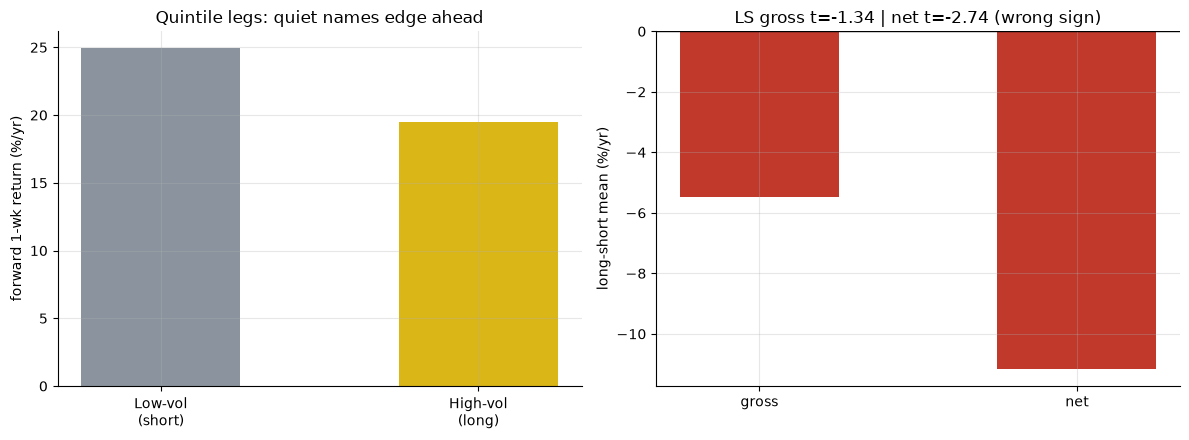

LS gross -5.47%/yr (Sharpe -0.388, t -1.343) | net -11.17%/yr (t -2.743)


In [4]:
if HAVE_REAL:
    ls_m, ls_t, ls_s = s_ls['mean']*100, s_ls['t_os'], s_ls['sharpe']
    lo_m, hi_m = s_short['mean']*100, s_long['mean']*100
    net_m, net_t = s_net['mean']*100, s_net['t_os']
else:
    ls_m, ls_t, ls_s = R['ls_mean'], R['ls_t'], R['ls_sharpe']
    lo_m, hi_m = R['short_leg'], R['long_leg']
    net_m, net_t = R['net_mean'], R['net_t']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(['Low-vol\n(short)', 'High-vol\n(long)'], [lo_m, hi_m],
            color=[GREY, AMBER], width=0.5)
axes[0].set_ylabel('forward 1-wk return (%/yr)')
axes[0].set_title('Quintile legs: quiet names edge ahead')
axes[1].bar(['gross', 'net'], [ls_m, net_m], color=[RED, RED], width=0.5)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('long-short mean (%/yr)')
axes[1].set_title(f'LS gross t={ls_t:+.2f} | net t={net_t:+.2f} (wrong sign)')
plt.tight_layout(); plt.show()
print(f'LS gross {ls_m:+.2f}%/yr (Sharpe {ls_s:+.3f}, t {ls_t:+.3f}) | '
      f'net {net_m:+.2f}%/yr (t {net_t:+.3f})')

### 4d -- The label-shuffle null distribution

Permute the volume labels across names within each week, 200 times, and build the null distribution of the mean long-short. Where does the real mean fall?

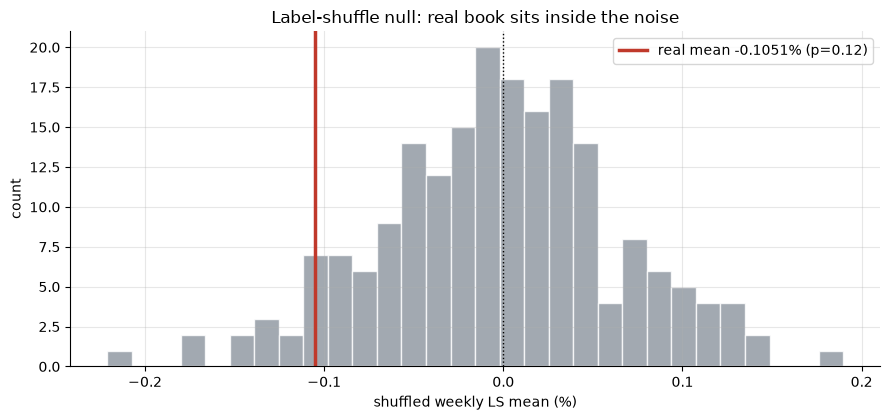

placebo p = 0.120


In [5]:
if HAVE_REAL:
    rm = float(ls['ls_gross'].mean())
    abn_mat, fwd_mat = st._signal_and_forward(ret, vol, 1, st.TRAIL_WEEKS, st.MIN_NAMES)
    rng = np.random.default_rng(512); draws = []
    for _ in range(200):
        sh = abn_mat.copy()
        for w in range(sh.shape[0]):
            v = ~np.isnan(sh[w]); vals = sh[w, v]; rng.shuffle(vals); sh[w, v] = vals
        draws.append(np.nanmean(st._long_short_means(sh, fwd_mat, st.QUINTILE)))
    draws = np.array(draws)*100; rm100 = rm*100
    p = float((np.abs(draws) >= abs(rm100)).mean())
    fig, ax = plt.subplots(figsize=(9.0, 4.3))
    ax.hist(draws, bins=30, color=GREY, edgecolor='white', alpha=0.8)
    ax.axvline(rm100, c=RED, lw=2.5, label=f'real mean {rm100:+.4f}% (p={p:.2f})')
    ax.axvline(0, c='k', lw=1, ls=':')
    ax.set_xlabel('shuffled weekly LS mean (%)'); ax.set_ylabel('count')
    ax.set_title('Label-shuffle null: real book sits inside the noise')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'placebo p = {p:.3f}')
else:
    print(f'Frozen placebo p = {R["placebo_p"]:.3f} '
          f'(seeds {R["placebo_p_seeds"]})')

### 4e -- Horizon robustness

Does a longer hold rescue it? The GKM story says the drift plays out over a few weeks; if the sign is wrong it should *worsen* with horizon.

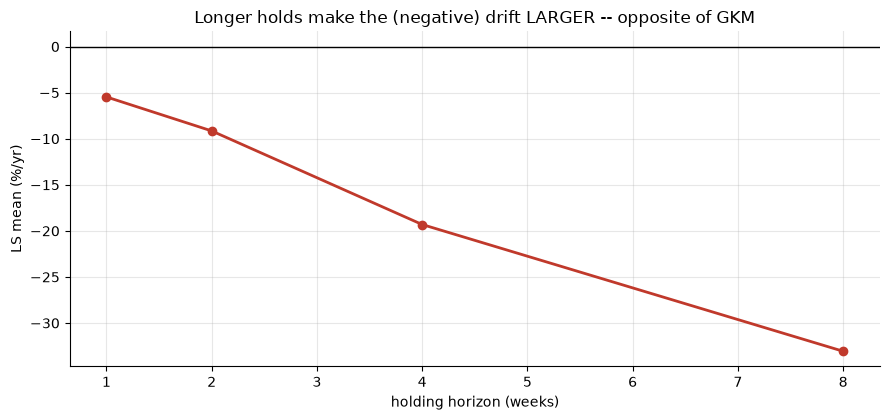

 horizon_wk  mean_%/yr   t_os  sharpe
          1     -5.466 -1.343  -0.388
          2     -9.153 -1.613  -0.467
          4    -19.310 -2.301  -0.667
          8    -33.064 -2.703  -0.786


In [6]:
if HAVE_REAL:
    rows = []
    for h in (1, 2, 4, 8):
        dh = st.long_short(ret, vol, horizon=h)
        s = st.summary(dh['ls_gross'])
        rows.append({'horizon_wk': h, 'mean_%/yr': s['mean']*100,
                     't_os': s['t_os'], 'sharpe': s['sharpe']})
    hz = pd.DataFrame(rows)
else:
    hz = pd.DataFrame([{'horizon_wk': h, 'mean_%/yr': v[0], 't_os': v[1], 'sharpe': v[2]}
                       for h, v in R['horizon'].items()])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(hz['horizon_wk'], hz['mean_%/yr'], 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('holding horizon (weeks)'); ax.set_ylabel('LS mean (%/yr)')
ax.set_title('Longer holds make the (negative) drift LARGER -- opposite of GKM')
plt.tight_layout(); plt.show()
print(hz.round(3).to_string(index=False))

### 4f -- Equity curve and turnover

The cumulative long-short and the weekly turnover that drives the cost drag.

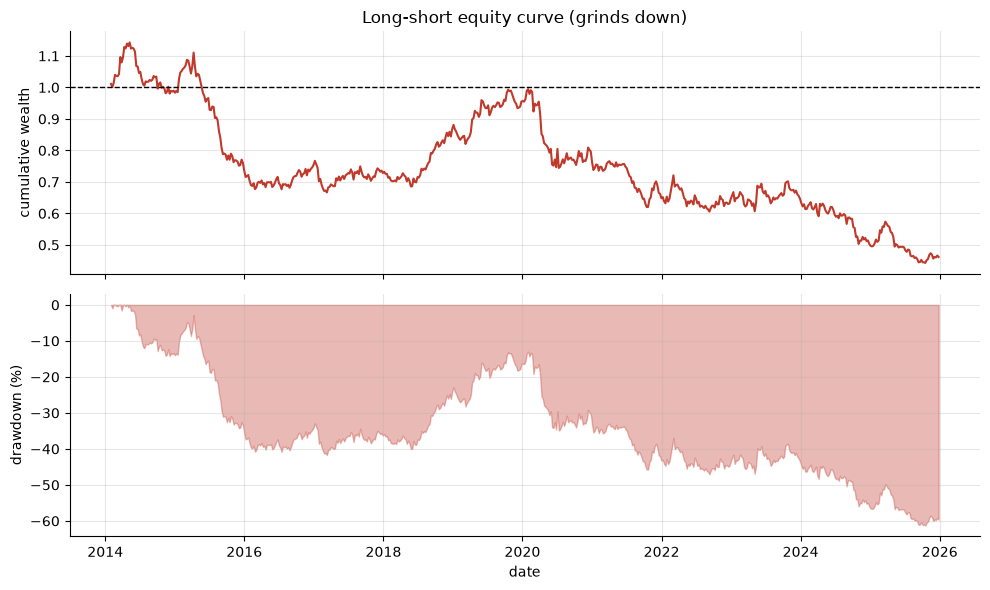

avg one-sided long-leg turnover: 64.5%/week | max DD -61.3%


In [7]:
if HAVE_REAL:
    eq = (1 + ls['ls_gross']).cumprod()
    dd = (eq/eq.cummax() - 1)*100
    turn = st.avg_turnover(ret, vol, horizon=1)
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    a1.plot(ls.index, eq.values, c=RED, lw=1.5); a1.axhline(1, c='k', lw=1, ls='--')
    a1.set_ylabel('cumulative wealth'); a1.set_title('Long-short equity curve (grinds down)')
    a2.fill_between(ls.index, dd.values, 0, color=RED, alpha=0.35)
    a2.set_ylabel('drawdown (%)'); a2.set_xlabel('date')
    plt.tight_layout(); plt.show()
    print(f'avg one-sided long-leg turnover: {turn*100:.1f}%/week | max DD {dd.min():.1f}%')
else:
    print(f'Frozen: turnover ~{R["turnover"]:.1f}%/wk | max DD {R["ls_dd"]:.1f}%')

## 5 -- The verdict

- **Signal `NONE`** -- LS -5.47%/yr, one-sample *t* = -1.343 (wrong sign), placebo p = 0.12 (seed-robust (0.125, 0.1, 0.117)). The premium does not replicate on modern large-caps.
- **Tradability `MIRAGE`** -- Sharpe -0.388, net -11.2%/yr, ~64%/wk turnover, max DD -61.3%. Even a right-signed book would drown in churn.
- **Survivorship `NAMED`** -- the biggest volume spikes belong to the delisted names a survivor basket removes. Magnitude is an upper bound (already negative).

## 6 -- Could you trade it?

No. Beyond the wrong sign:

1. **Turnover.** ~64% of the long basket changes every week. At 5 bps/leg the cost line alone is several percent a year.
2. **Short borrow.** Shorting the quiet names is cheap but not free; charged at 50 bps/yr here.
3. **Decay & crowding.** A 1-week mega-cap signal is the first thing competed away; McLean-Pontiff (2016) document ~32% post-publication attenuation on average, and GKM is a 2001 paper.

## 7 -- Going further

- **Small/mid-caps.** The recognition channel needs visibility headroom; the premium is documented as strongest away from the most-watched names.
- **Point-in-time universe with delisted names.** Re-admit the blow-up / takeover names that trade on the biggest spikes -- the natural shorts.
- **Daily-formation variant.** GKM also test day-formation; a daily sort changes the turnover/cost trade-off.
- **[Study 238 -- Betting-Against-Beta](../../238-betting-against-beta/)** and **[Study 330 -- Low-Volatility-Anomaly](../../330-low-volatility-anomaly/)**: the same cross-sectional-sort infrastructure on risk signals.
- **[Study 418 -- Money-Flow-Index](../../418-money-flow-index/)**: the nearest volume-indicator neighbour.

*Think the high-volume premium survives net of costs on a point-in-time universe with delisted names? Fork this, widen to small/mid-caps, and show t > 2 net. That is the bar.*